[ 7.93920250e-01 -5.57310508e-02  4.73232387e-01 -6.65175173e-04]


Text(0, 0.5, 'den')

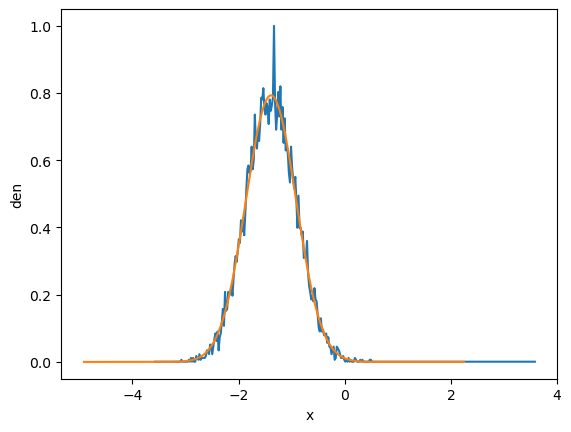

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
 
# 读取数据，指定分隔符为空格
data = pd.read_csv('test.txt', header=None, delim_whitespace=True)
 
x = data.iloc[0,:].values
den = data.iloc[1,:].values 
# print(den)
plt.figure
plt.plot(x,den)
plt.xlabel("x")
plt.ylabel("den")


from scipy.optimize import curve_fit
def Gauss(x,a,x0,sigma,c):    
    y = a*np.exp(-(x-x0)**2/(2*sigma**2))+c
    return y

max_den = np.max(den)  # 最大值
max_index = np.argmax(den)  # 最大值对应的索引
x0_initial = x[max_index]  # 对应的x坐标作为x0初始值
initial_guess = [max_den, x0_initial, 1.0, np.min(den)] 

popt,pcov = curve_fit(Gauss,x-x0_initial,den) 
print(popt)
fit_denx = Gauss(x, popt[0], popt[1], popt[2], popt[3], p0=initial_guess)
plt.plot(x+x0_initial,fit_denx)
plt.xlabel("x")
plt.ylabel("den")

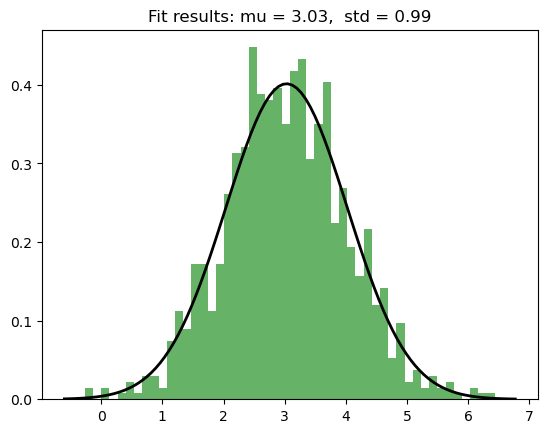